# **Bot's classification problem**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import ParameterGrid
from metric import precision_at_recall
from catboost import CatBoostClassifier


### Задача состоит в бинарной классификации cookie (в дальнейшем просто куки) на два класса: **человек и бот**. 

<div style="line-height: 1.8;">

В отличие от задач, где объект уже представлен фиксированным набором признаков, здесь исходные данные имеют событийную структуру. Для каждой куки доступна последовательность действий, совершённых в ограниченном временном окне.

Исходя из этого,    
    
    основной этап решения связан с переходом от последовательности событий к признаковому описанию поведения куки.

Один и тот же объём активности может соответствовать принципиально разным сценариям: человек может последовательно просматривать несколько объявлений, возвращаться к уже открытым объектам и переходить от поиска к карточке товара, тогда как автоматизированная активность может отличаться другим временным ритмом, структурой переходов и разнообразием действий. Отдельное событие в большинстве случаев слабо информативно; интерес представляет их распределение и взаимное расположение во времени.

В качестве основной метрики используется **Precision@Recall=0.7**. Такая постановка требует сохранить не менее 70% объектов положительного класса и среди них максимизировать precision.

### **Feature_engineering_research**

<div style="line-height: 1.8;">
Работа строилась в два этапа.

    Основная исследовательская часть велась в отдельном ноутбуке feature_engineering_research. 

Пожалуйста, изучите! В нём последовательно проверялись различные группы признаков, проводились эксперименты с разными группами и анализировался вклад новых переменных в значение целевой метрики. Текущий ноутбук содержит уже собранный вариант решения.
При построении решения учитывается временная природа данных. Признаки для куки вычисляются только по событиям, попадающим в заданное окно наблюдения, а качество модели оценивается на более поздних временных интервалах. Это позволяет приблизить схему валидации к ситуации, в которой модель обучается на уже известной истории и затем применяется к новым данным.

## **№0. Данные**

In [3]:
#Даты
metadata_dates = [
    "cookie_created_at",
    "window_start_ts",
    "window_end_ts",
]

train = pd.read_csv("data/train.csv", parse_dates=metadata_dates)
test = pd.read_csv("data/test.csv", parse_dates=metadata_dates)
events = pd.read_csv("data/events.csv.gz", parse_dates=["event_ts"])

print(train.shape, test.shape, events.shape)
print('доля ботов в train:', train.target.mean().round(4)) 

(11091, 5) (4909, 4) (328905, 14)
доля ботов в train: 0.0811


Доля положительного класса в train составляет 8.11%  - классы заметно несбалансированы.

### **Агрегация по признакам только внутри окна**

<div style="line-height: 1.8;">

Признаки считаем только по событиям внутри окна: window_start_ts <= event_ts < window_end_ts. Это требование из условия, а не рекомендация.

In [4]:
def events_in_window(events, meta):
    ev = events.merge(meta[['cookie_id', 'window_start_ts', 'window_end_ts']], on='cookie_id', how = 'inner', validate = 'many_to_one')
    return ev[(ev.event_ts >= ev.window_start_ts) & (ev.event_ts < ev.window_end_ts)]

ev_tr = events_in_window(events, train)
ev_te = events_in_window(events, test)
print("События train внутри окна:", len(ev_tr))
print("События test внутри окна:", len(ev_te))

События train внутри окна: 198436
События test внутри окна: 89690


### **Дубликаты**

<div style="line-height: 1.8;">

Повторное присутствие одной и той же записи искусственно увеличивает число действий куки и может искажать временные и частотные признаки. Удаляем полные дубликаты

In [5]:
#Дубликаты

event_columns = events.columns.to_list()

dubl_train = ev_tr.duplicated(subset = event_columns).sum()
dubl_test = ev_te.duplicated(subset = event_columns).sum()

print("Дубликаты train:", dubl_train)
print("Дубликаты test:", dubl_test)

ev_tr = ev_tr.drop_duplicates(subset = event_columns).copy()
ev_te = ev_te.drop_duplicates(subset = event_columns).copy()

print(f'Осталось в трейне: {len(ev_tr)}')
print(f'Осталось в тесте: {len(ev_te)}')


Дубликаты train: 2952
Дубликаты test: 1341
Осталось в трейне: 195484
Осталось в тесте: 88349


### **Нормализация платформы в ev_tr/ev_te**

Признак **platform** содержит несколько строковых вариантов для одних и тех же платформ. Приводим названия к нижнему регистру и к трём значениям: web, android и ios.

In [6]:
'''
Всё в нижний регистр,
"WEB", "Web", "desktop"  в "web";
"ANDROID", "Android"  в "android";
"IOS", "iOS", "iphone" в "ios".
'''

for ev in (ev_tr, ev_te):
    ev['platform_norm'] = (
        ev['platform'].astype('string').str.strip()
        .str.lower()
        .replace({
            'desktop' : 'web',
            'iphone' : 'ios',
            "" : pd.NA,
        })
    )
print(ev_tr['platform_norm']. value_counts(dropna = False))

platform_norm
web        108382
android     76826
ios         10276
Name: count, dtype: Int64


## **№1. Работа с пропусками**

### Построим матрицу **statistic_matrix**

In [7]:
#Пропуски
n_missing = ev_tr.isna().sum() 
percenr_of_isna = n_missing/len(ev_tr) * 100

statistic_matrix = pd. DataFrame({
    "n_missing" : n_missing,
    "percent_of_isna" : percenr_of_isna.round(2),
    "dtype" : ev_tr.dtypes.astype(str),
    "n_unique" : ev_tr.nunique()
})
statistic_matrix

,n_missing,percent_of_isna,dtype,n_unique
cookie_id,0,0.00,object,11091
event_ts,0,0.00,datetime64[ns],178059
eid,0,0.00,int64,9
event_name,0,0.00,object,9
platform,0,0.00,object,11
user_agent,0,0.00,object,148
item_id,64654,33.07,float64,46953
item_category,15400,7.88,object,15
item_location,9691,4.96,object,40
seller_type,76517,39.14,object,2


### Оценим признаки не с **нулевым n_missing**

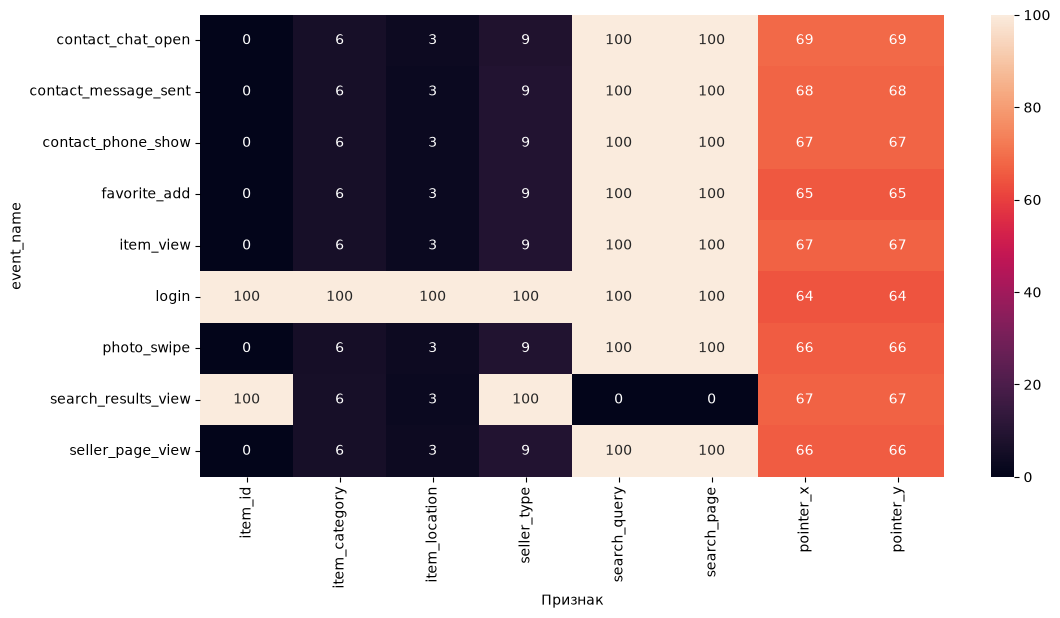

In [8]:
columns_to_check = statistic_matrix.loc[
    statistic_matrix['n_missing'] != 0,
].index.to_list()

#Таблица показывает,как пропуски распределены между событиями event_name
missing_by_event = (
    ev_tr[columns_to_check]
    .isna()
    .groupby(ev_tr["event_name"])
    .mean()
    .mul(100)
    .round(2)
)

#хитмапа 
plt.figure(figsize=(12,6))

sns.heatmap(
    missing_by_event,
    annot = True,
    fmt='.0f'
    
)

plt.xlabel('Признак')
plt.ylabel('event_name')
plt.show()

### Отдельно посмотрим на **координаты**

In [9]:
#Координаты на разных платформах
pointer_by_platform_x = (
    ev_tr.groupby('platform_norm')['pointer_x']
    .apply(lambda x: x.notna().mean() * 100)
)
pointer_by_platform_y = (
    ev_tr.groupby('platform_norm')['pointer_y']
    .apply(lambda x: x.notna().mean() * 100)
)

print(pointer_by_platform_x)
print(pointer_by_platform_y) 
#Да, логично, что одинаково

platform_norm
android     0.000000
ios         0.000000
web        60.234172
Name: pointer_x, dtype: float64
platform_norm
android     0.000000
ios         0.000000
web        60.234172
Name: pointer_y, dtype: float64


Чётко видно **отсутствие** координат на Android или iOS

#### Посмотрим на пропуски при **event_name = login**

In [10]:
#login
login_percent = (
    ev_tr.loc[ev_tr['event_name'] == 'login']
    .notna()
    .mean()
    .round(2) * 100)
login_percent

cookie_id          100.0
event_ts           100.0
eid                100.0
event_name         100.0
platform           100.0
user_agent         100.0
item_id              0.0
item_category        0.0
item_location        0.0
seller_type          0.0
search_query         0.0
search_page          0.0
pointer_x           36.0
pointer_y           36.0
window_start_ts    100.0
window_end_ts      100.0
platform_norm      100.0
dtype: float64

#### **Выжный вывод по пропускам. Везде NaN оставляем и вот почему**
<div style="line-height: 1.8;">

**Во-первых**, если удалить все строки хотя бы с одним NaN, то полностью потеряем таблицу.

**Во-вторых**, тут важно уточнить, что пропуски могут быть **двух видов**: 

**Структурные (или логичные) и пропуски из за отсутствия инофрмации**.

1. **Структурные пропуски**

    Например, у **item_view** (просмотра объявления) нет поискового запроса (**search_query**), у **search_results_view**(просмотра поисковой выдачи) нет **item_id** (айдишника объявления), а у **login** (события входа в аккаунт) отсутствуют поля, связанные с поиском и объявлениями. Суммируя, это связано с типом события - структурные пропуски - поэтому такие строки не удаляем. Признаки поиска считаем по **search_results_view**, характеристики объявлений только по тем событиям, где они доступны.


2. **Обычные пропуски**

    Для **item_view**: **item_category** (категория товара) отсутствует в 6,01% случаев, **item_location** (локация) в 3,00%, **seller_type** (тип продавца) в 9,08%. Причину отсутствия этих значений мы не знаем - может быть особенность сбора данных или источника. **Не заполняем эти значения нулями или ещё чем-то**, т.к. это может дать лишнюю лживую информацию модели. Разнообразие  категорий и локаций считаем по известным значениям. Дополнительно сохраняем число заполненных наблюдений и долю пропусков. Доли типов продавцов считаем только по строкам, где **seller_type** известен. Если таких строк нет, оставляем NaN.

3. Отдельно хочется сказать про **login** и **pointer_x**/**pointer_y**

    Строки с **login** в качестве событий агрегируют на себе большое количество пропусков. Прям так и хочется выбросить данные строки. Но! Большинство пропусков - структурные, что защищает их от замены, но что ещё важнее, **event_name = login** участвуют в общих счётчиках и общих временных признаках. Например:

        - время действия;

        - платформу и User-Agent;

        - сам факт входа;

    **Координаты тоже не заполняем нулями**. На мобильных платформах они отсутствуют полностью, поэтому при анализе координат нужно учитывать платформу. Если заполнить нулями: (0,0), - это реальная позиция - опять ложь для модели. 

    После агрегации по **cookie_id** нулём заполняем только счётчики действий. Например, если у пользователя не было **search_results_view**, количество поисков равно 0, но максимальную страницу выдачи определить нельзя, поэтому там остаётся NaN. То же самое с временными признаками: если событие было только одно, интервал между событиями посчитать невозможно.

## **№2. Features (функция build_features)**

    Основная работа по генерации и отбору признаков проводилась в ноутбуке feature_engineering_research. Пожалуйста изучите! 
    
<div style="line-height: 1.8;">

В нём новые группы признаков добавлялись к фиксированному бейзлайну по отдельности, после чего скор сравнивался на временной валидации. Для части экспериментов дополнительно использовался SHAP-анализ, а коррелирующие и производные признаки проверялись по одному. Такой подход позволил отделить признаки, которые  дают  сигнал, от большого числа технически возможных агрегатов, не улучшающих качество.

В итоговый набор вошли характеристики нескольких уровней поведения. 
1. Временные признаки описывают скорость и регулярность потока событий. 
2. Количественные признаки отражают общий объём активности и разнообразие просмотренных объектов. 
3. Категориальные признаки сохраняют информацию о самой частой платформе, User-Agent и локации у объявлений. 
4. Допом учитывается состав событий, особенности координат курсора и переходы между действиями.

Общий принцип: Последовательность событий преобразуется в одну строку таблицы признаков. Исходный порядок событий сохраняется при расчёте временных интервалов и переходов между соседними действиями

In [11]:
#Добавим гэп по времени: Если между соседними действиями одной куки прошло больше 30 минут, то это новая сессия

gap = 1800 #секунд (30 минут) - условная, удобная граница между сессиями

#Отсортируем куки по времени
for ev in (ev_tr, ev_te):
    ev.sort_values(
        ["cookie_id", "event_ts"],
        kind="stable",
        inplace=True,
    )
    #Гэпы в течение всего времени 
    ev["gap_s"] = (
        ev.groupby("cookie_id", sort=False)["event_ts"]
        .diff()
        .dt.total_seconds()
    )

    #Гэпы в течение одной сессии
    ev["within_gap_s"] = ev["gap_s"].where(
        ev["gap_s"] <= gap
    )

### Функция **build_features** собирает финальный набор признаков. 
<div style="line-height: 1.8;">

**Временной блок** включает:

        -Медиану длины временного интервала между событиями (`median_gap_s`);
        -10-й и 90-й процентили интервалов (`p10_gap_s`, `p90_gap_s`);
        -Средний интервал внутри сессии (`mean_within_gap_s`);
        -Коэффициент вариации внутрисессионных интервалов (`cv_within_gap_s`).


**Объём активности и разнообразие активности**:

        -Число событий (`n_events`);
        -Число уникальных объявлений (`item_nunique`);
        -Наиболее частые платформа и User-Agent (`main_platform`, `main_user_agent`);
        -Основная локация (`main_item_location`);
        -Число уникальных категорий и локаций объявлений 
        (`item_category_nunique`, `item_location_nunique`).


**Структура событий**:

        –Число различных типов событий (`n_event_type`);
        –Доля наиболее частого типа события (`dominant_event_share`);
        –Доля событий просмотра объявления (`share_item_view`);
        –Доля событий свайпа фото (`share_photo_swipe`);
        –Энтропия распределения типов событий (`event_entropy`).


**Характеристики курсора**:

        –Медианное положение указателя по оси X (`pointer_x_median`);
        –Стандартное отклонение координаты по оси X (`pointer_x_std`);
        –Стандартное отклонение координаты по оси Y (`pointer_y_std`);
        –Число web-событий с доступными координатами указателя (`n_pointer`).


**Поведенческий блок** включает:

        -Возраст cookie в часах (`cookie_age_hours`);
        –Долю повторных просмотров уже просмотренных объявлений (`repeat_view_share`);
        –Медианное время перехода item_view → item_view (`median_item_to_item_s`);
        –Медианное время перехода search_results_view → item_view (`median_search_to_item_s`);
        –Медианное время перехода item_view → search_results_view (`median_item_to_search_s`);
        –Долю событий, связанных с контактом с продавцом (`contact_share`);
        –Максимальную достигнутую страницу поисковой выдачи (`max_search_page`).


Числовые NaN после агрегации сохраняются, если значение признака объективно невозможно вычислить.

In [12]:
#Данная функция является результатом большой работы, представленной в ноутбук feature_engineering_research

def build_features(ev, meta):
    grouped = ev.groupby("cookie_id", sort=False)

    # Временные признаки
    timed = grouped.agg(
        median_gap_s=("gap_s", "median"),
        p10_gap_s=("gap_s", lambda x: x.quantile(0.10)),
        p90_gap_s=("gap_s", lambda x: x.quantile(0.90)),
        mean_within_gap_s=("within_gap_s", "mean"),
        std_within_gap_s=("within_gap_s", "std"),
    )

    timed["cv_within_gap_s"] = (
        timed["std_within_gap_s"]
        / timed["mean_within_gap_s"].replace(0, np.nan)
    )
    timed = timed.drop(columns="std_within_gap_s")

    # Объём активности
    basic = grouped.agg(
        n_events=("event_ts", "size"),
        item_nunique=("item_id", "nunique"),
    )

    def mode_or_unknown(values):
        values = values.dropna()
        return values.value_counts().idxmax() if len(values) else "unknown"

    # Платформа, User-Agent и содержимое объявлений
    technical = grouped.agg(
        main_platform=("platform_norm", mode_or_unknown),
        main_user_agent=("user_agent", mode_or_unknown),
    )

    content = grouped.agg(
        main_item_location=("item_location", mode_or_unknown),
        item_category_nunique=("item_category", "nunique"),
        item_location_nunique=("item_location", "nunique"),
    )

    pointer = (
        ev.loc[
            ev["platform_norm"].eq("web")
            & ev["pointer_x"].notna()
            & ev["pointer_y"].notna()
        ]
        .groupby("cookie_id")
        .agg(
            pointer_x_median=("pointer_x", "median"),
            pointer_y_median = ("pointer_y", 'median'),
            pointer_x_std=("pointer_x", "std"),
            pointer_y_std=("pointer_y", "std"),
            n_pointer=("pointer_x", "size"),
        )
    )

    views = ev.loc[ev["event_name"].eq("item_view") & ev["item_id"].notna()]
    items = views.groupby("cookie_id")["item_id"]
    previous = grouped["event_name"].shift()
    contact = ev["event_name"].isin([
        "contact_phone_show", "contact_chat_open", "contact_message_sent"
    ])

    behavior = pd.DataFrame({
        "repeat_view_share": 1 - items.nunique() / items.size(),
        "median_item_to_item_s": ev["gap_s"].where(
            ev["event_name"].eq("item_view") & previous.eq("item_view")
        ).groupby(ev["cookie_id"]).median(),
        "median_search_to_item_s": ev["gap_s"].where(
            ev["event_name"].eq("item_view") & previous.eq("search_results_view")
        ).groupby(ev["cookie_id"]).median(),
        "median_item_to_search_s": ev["gap_s"].where(
            ev["event_name"].eq("search_results_view") & previous.eq("item_view")
        ).groupby(ev["cookie_id"]).median(),
        "contact_share": contact.groupby(ev["cookie_id"]).mean(),
        "max_search_page": ev.loc[
            ev["event_name"].eq("search_results_view")
        ].groupby("cookie_id")["search_page"].max(),
    })
    behavior.index.name = "cookie_id"

    # Cтруктура событий
    event_counts = (
        ev.groupby(["cookie_id", "event_name"])
        .size()
        .unstack(fill_value=0)
    )
    event_shares = event_counts.div(
        event_counts.sum(axis=1),
        axis=0,
    )

    structure = pd.DataFrame(index=event_counts.index)
    structure["n_event_type"] = event_counts.gt(0).sum(axis=1)
    structure["dominant_event_share"] = event_shares.max(axis=1)
    
    structure["share_item_view"] = (
        event_shares["item_view"]
        if "item_view" in event_shares.columns
        else 0
    )
    
    structure["share_photo_swipe"] = (
        event_shares["photo_swipe"]
        if "photo_swipe" in event_shares.columns
        else 0
    )

    nonzero_shares = event_shares.where(event_shares > 0)
    structure["event_entropy"] = -(
        nonzero_shares * np.log(nonzero_shares)
    ).sum(axis=1)

    features = meta[["cookie_id"]].copy()

    for part in (timed, basic, technical, content, structure, pointer, behavior):
        features = features.merge(
            part.reset_index(),
            on="cookie_id",
            how="left",
            validate="one_to_one",
        )

    # Отсутствие событий означает нулевые счётчики.
    for column in ("n_events", "item_nunique"):
        features[column] = (
            features[column].fillna(0).astype("int64")
        )

    for column in (
        "main_platform",
        "main_user_agent",
        "main_item_location",
    ):
        features[column] = (
            features[column].fillna("unknown").astype(str)
        )

    features["locations_per_item"] = (
        features["item_location_nunique"]
        / features["item_nunique"].replace(0, np.nan)
    )

    features["cookie_age_hours"] = (
        meta["window_start_ts"] - meta["cookie_created_at"]
    ).dt.total_seconds().to_numpy() / 3600

    columns = [
        "cookie_id",
        "median_gap_s",
        "p10_gap_s",
        "p90_gap_s",
        "cv_within_gap_s",
        "mean_within_gap_s",
        "n_events",
        "item_nunique",
        "main_platform",
        "main_user_agent",
        "main_item_location",
        "item_category_nunique",
        "item_location_nunique",
        "n_event_type",
        "dominant_event_share",
        "share_item_view",
        "share_photo_swipe",
        "event_entropy",
        "locations_per_item",
        "pointer_x_median",
        "pointer_x_std",
        "pointer_y_std",
        "n_pointer",
        "cookie_age_hours",
        "repeat_view_share",
        "median_item_to_item_s",
        "median_search_to_item_s",
        "median_item_to_search_s",
        "contact_share",
        "max_search_page",
    ]

    features = features[columns]
    assert features["cookie_id"].equals(meta["cookie_id"])
    return features

In [13]:
base_tr = build_features(ev_tr, train)
base_te = build_features(ev_te, test)
cat_cols = [
    "main_item_location",
    "main_platform",
    "main_user_agent",
]

## **№3. ML (CatBoost only)**



<div style="line-height: 1.8;">

Итоговая модель строится на **CatBoost**. В датасете одновременно присутствуют непрерывные признаки, счётчики, значения с пропусками и категориальные характеристики. Много нелинейных зависимостей. CatBoost позволяет передавать категориальные признаки непосредственно модели + представляет собой реализацию градиентного бустинга на деревьях решений, что позволяет моделировать нелинейные зависимости. 

Подбор модели проводится по целевой метрике P@R0.7.   
**Logloss** используется только как функция оптимизации CatBoost.



### **Подбор гиперпараметров на 3х временных фолдах**

<div style="line-height: 1.8;">

Случайное разбиение объектов на train и val здесь не подходит. Данные имеют временную структуру, а распределение активности может меняться между соседними периодами.

Для каждого фолда модель обучается только на объектах, окно которых полностью заканчивается до начала validation-периода

In [ ]:
#Создание временных фолдов
X = base_tr.drop(columns="cookie_id") #Весь датасет
y = train["target"]

fold_specs = [
    ("12–13 апреля", "2026-04-12", "2026-04-14"),
    ("14–16 апреля", "2026-04-14", "2026-04-17"),
    ("17–19 апреля", "2026-04-17", "2026-04-20")

]

time_folds = []

for name, start, end in fold_specs:
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)

    train_rows = train["window_end_ts"] <= start
    valid_rows = ((train["window_start_ts"] >= start) & (train["window_start_ts"] < end))

    time_folds.append((name, train_rows, valid_rows))

    fold_model = CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        random_seed=0,
        verbose=False,
        allow_writing_files=False,
    )

    fold_model.fit(
        X.loc[train_rows],
        y.loc[train_rows],
        cat_features=cat_cols,
    )

    scores = fold_model.predict_proba(X.loc[valid_rows])[:, 1]
    result = precision_at_recall(y.loc[valid_rows], scores)

    print( f"P@R0.7={result:.4f}")

P@R0.7=0.8317
P@R0.7=0.6919
P@R0.7=0.8370


In [ ]:
#Проход по сетке
param_grid = {
    "depth": [4, 6],
    "iterations": [300, 400, 500, 700],
    "l2_leaf_reg": [3, 10, 15],
}

results = []

for params in ParameterGrid(param_grid):
    fold_scores = []

    for name, train_rows, valid_rows in time_folds:
        fold_model = CatBoostClassifier(
            **params,
            learning_rate=0.05,
            loss_function="Logloss",
            random_seed=0,
            verbose=False,
            allow_writing_files=False,
        )

        fold_model.fit(
            X.loc[train_rows],
            y.loc[train_rows],
            cat_features=cat_cols,
        )

        scores = fold_model.predict_proba(
            X.loc[valid_rows]
        )[:, 1]

        fold_scores.append(
            precision_at_recall(y.loc[valid_rows], scores)
        )

    results.append({
        **params,
        "P@R_12_13": fold_scores[0],
        "P@R_14_16": fold_scores[1],
        "P@R_17_19": fold_scores[2],
        "mean_P@R": np.mean(fold_scores),
        "min_P@R": np.min(fold_scores),
    })

    print(
        params,
        "→",
        [round(score, 4) for score in fold_scores],
    )

results_df = (
    pd.DataFrame(results)
    .sort_values(
        ["mean_P@R", "min_P@R"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(results_df.round(4))

{'depth': 4, 'iterations': 300, 'l2_leaf_reg': 3} → [0.8095, 0.6524, 0.7692]
{'depth': 4, 'iterations': 300, 'l2_leaf_reg': 10} → [0.8155, 0.6749, 0.7467]
{'depth': 4, 'iterations': 300, 'l2_leaf_reg': 15} → [0.785, 0.7165, 0.7687]
{'depth': 4, 'iterations': 400, 'l2_leaf_reg': 3} → [0.8269, 0.6881, 0.7778]
{'depth': 4, 'iterations': 400, 'l2_leaf_reg': 10} → [0.8317, 0.6716, 0.7619]
{'depth': 4, 'iterations': 400, 'l2_leaf_reg': 15} → [0.7944, 0.7211, 0.7733]
{'depth': 4, 'iterations': 500, 'l2_leaf_reg': 3} → [0.84, 0.6618, 0.7832]
{'depth': 4, 'iterations': 500, 'l2_leaf_reg': 10} → [0.8571, 0.6683, 0.7793]
{'depth': 4, 'iterations': 500, 'l2_leaf_reg': 15} → [0.84, 0.7062, 0.7793]
{'depth': 4, 'iterations': 700, 'l2_leaf_reg': 3} → [0.84, 0.6406, 0.7847]
{'depth': 4, 'iterations': 700, 'l2_leaf_reg': 10} → [0.8485, 0.6683, 0.8]
{'depth': 4, 'iterations': 700, 'l2_leaf_reg': 15} → [0.8365, 0.7062, 0.8]
{'depth': 6, 'iterations': 300, 'l2_leaf_reg': 3} → [0.8173, 0.6935, 0.8071]
{'de

,depth,iterations,l2_leaf_reg,P@R_12_13,P@R_14_16,mean_P@R,min_P@R
0,6,700,3,0.8333,0.7211,0.7872,0.7211
1,6,500,3,0.8317,0.6919,0.7869,0.6919
2,6,500,15,0.8600,0.6990,0.7863,0.6990
3,6,400,3,0.8155,0.6919,0.7832,0.6919
4,4,700,15,0.8365,0.7062,0.7809,0.7062
5,6,400,15,0.8500,0.6850,0.7783,0.6850
6,6,700,10,0.8571,0.6749,0.7778,0.6749
7,6,400,10,0.8660,0.6782,0.7776,0.6782
8,6,700,15,0.8515,0.6667,0.7766,0.6667
9,4,500,15,0.8400,0.7062,0.7752,0.7062


## **Финальная модель**

#### Подобранные гиперпараметры используются для обучения на всей выборке X

In [18]:
#Проверки
assert base_te.columns.equals(base_tr.columns)
assert base_te["cookie_id"].equals(test["cookie_id"])

best_params = {
    'depth' : 6,
    'iterations' : 700,
    'l2_leaf_reg' : 3
 }
final_model = CatBoostClassifier(
    **best_params,
    learning_rate=0.05,
    loss_function="Logloss",
    random_seed=0,
    verbose=False,
    allow_writing_files=False,
)

final_model.fit(X, y, cat_features=cat_cols)

test_scores = final_model.predict_proba(base_te[X.columns])[:, 1]

predictions = pd.DataFrame({
    "cookie_id": test["cookie_id"],
    "score": test_scores,
})
assert len(predictions) == len(test) and predictions.score.between(0, 1).all()
predictions.to_csv('submission.csv', index=False)
display(predictions.head())

,cookie_id,score
0,ck_315fb710a0e371e7,0.000640
1,ck_a76ee3b3e3e522fd,0.049965
2,ck_94c9a4d382689e82,0.038166
3,ck_8eaf9509ad9462a0,0.000587
4,ck_9a88a5a989cb5bc6,0.002750
